In [73]:
import cafe
import scanpy as sc

cafe.settings.backend = "python_function"
cafe.logger.setLevel("DEBUG")
import pandas as pd
import numpy as np
from cafe.data import FateAnnData
from cafe.metric.metric_correlation_v2 import calculate_correlation
from cafe.metric.metric_position_predict_v2 import calculate_position_predict
from cafe.metric.metric_featureimp_v2 import (
    calculate_overall_feature_importance,
    calculate_featureimp_cor,
    calculate_featureimp_enrichment,
    fi_ranger_rf_tiny,
)
from cafe.metric.cluster_metric_v2 import calculate_mapping_branches, calculate_mapping_milestones, calculate_mapping
from cafe.metric._topology_metric.metric_him import calculate_him
from cafe.metric.topology_metric import calc_isomorphic, calculate_edge_flip

In [74]:
# 读取scvelo的pancreas数据
adata = sc.read_h5ad("/home/huang/PyCode/scRNA/data/Pancreas/endocrinogenesis_day15.h5ad")
fadata = cafe.data.FateAnnData.from_anndata(adata)
fadata.layers["expression"] = fadata.layers["spliced"]
fadata.layers["count"] = fadata.layers["spliced"]

basis = "umap"

sc.pp.subsample(fadata, n_obs=2000)

fadata

[2025年04月24日 20时34分35秒] DEBUG    Create a FateAnnData object from an existing AnnData object.                
                        DEBUG    Create a FateAnnData object from an existing AnnData object.                      


AnnData object with n_obs × n_vars = 2000 × 27998
    obs: 'clusters_coarse', 'clusters', 'S_score', 'G2M_score'
    var: 'highly_variable_genes'
    uns: 'clusters_coarse_colors', 'clusters_colors', 'day_colors', 'neighbors', 'pca', 'cfe'
    obsm: 'X_pca', 'X_umap'
    layers: 'spliced', 'unspliced', 'expression', 'count'

In [75]:
# 手动添加参考里程碑
milestone_network = pd.DataFrame(
    data=[
        ["Ductal", "Ngn3 low EP"],
        ["Ngn3 low EP", "Ngn3 high EP"],
        ["Ngn3 high EP", "Pre-endocrine"],
        ["Pre-endocrine", "Alpha"],
        ["Pre-endocrine", "Beta"],
        ["Pre-endocrine", "Delta"],
        ["Pre-endocrine", "Epsilon"],
    ],
    columns=["from", "to"],
)

fadata.add_trajectory_mannually(milestone_network)

[2025年04月24日 20时34分36秒] DEBUG    FateAnnData add_trajectory                                                  


[2025年04月24日 20时34分41秒] DEBUG    plot_trajectory                                                             
[2025年04月24日 20时34分45秒] DEBUG    add waypoints                                                               
                        DEBUG    FateAnnData add_waypoints                                                         
[2025年04月24日 20时34分46秒] DEBUG    add waypoints shape is (210, 2000), finished!                               


<Axes: title={'center': 'milestone_color'}, xlabel='UMAP1', ylabel='UMAP2'>

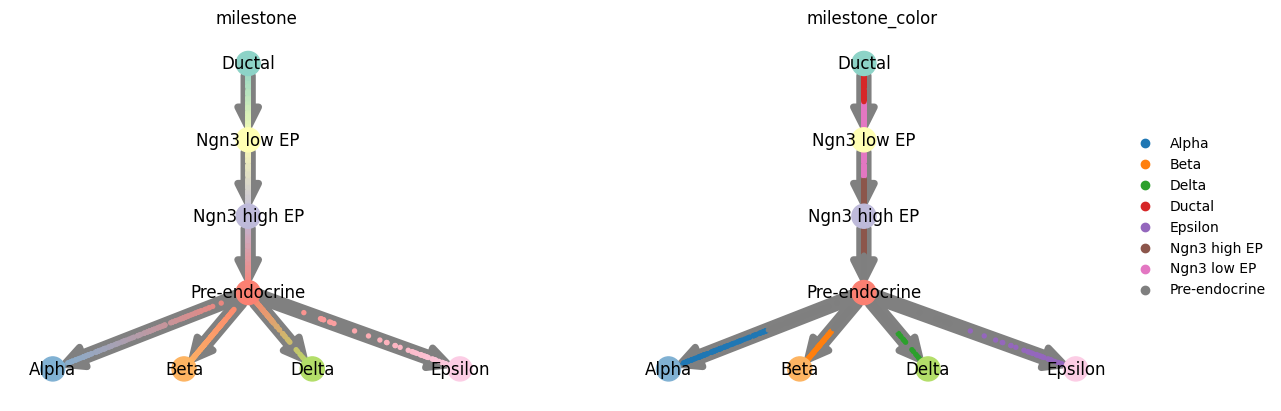

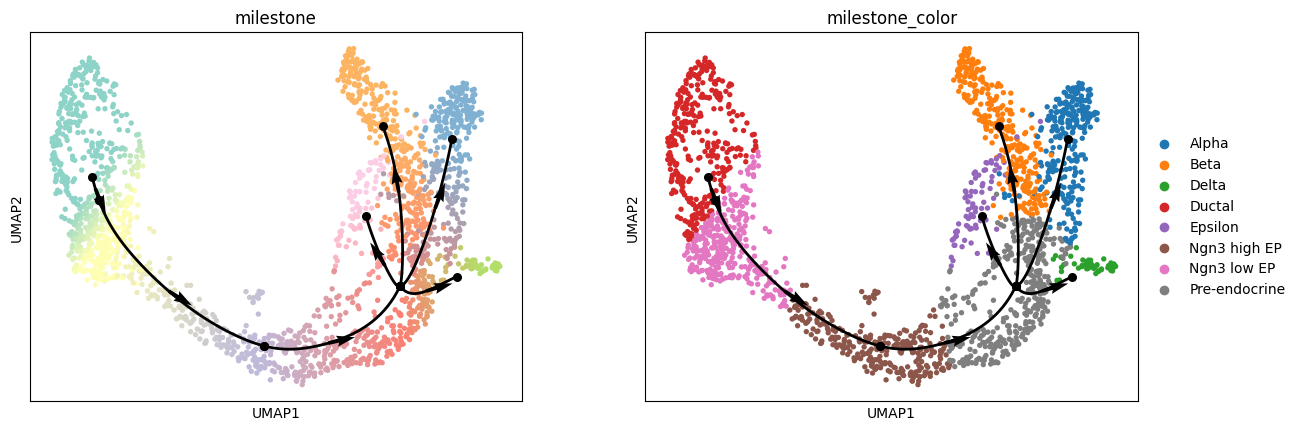

In [76]:
cluster_key = "milestone_color"
fadata.group_onto_nearest_milestones(cluster_key=cluster_key)  # new cluster color

cluster_key_list = ["milestone", cluster_key]
cafe.plot.plot_graph(fadata, color=cluster_key_list)
cafe.plot.plot_trajectory(fadata, basis=basis, color=cluster_key_list)

In [77]:
prior_information = {"start_id": fadata.obs.index[0], "groups_id": fadata.obs[cluster_key].tolist()}
parameters = {"filter_features": False, "connectivity_cutoff": 0.3}
fadata.add_prior_information(**prior_information)  # add prior information to fadata

In [78]:
method_name_list = ["comp1", "state_comp", "cluster_mst", "projection_mst", "graph_mst"]
for method_name in method_name_list:
    method = cafe.method.FateMethod(method_name=method_name)
    method.infer_trajectory(fadata)

[2025年04月24日 20时34分57秒] DEBUG    FunctionBackend __init__                                                    
                        INFO     Loaded function: <function cf_comp1 at 0x7c1764524dc0> from                       
                                 /home/mhn/Code/CellFateExplorer/cfe/method/function/cf_comp1.py                   
                        INFO     method_backend: <cafe.method.fate_function_backend.FunctionBackend object at       
                                 0x7c176459b940>                                                                   
                        DEBUG    FateAnnData add_trajectory                                                        
                        DEBUG    FunctionBackend __init__                                                          
                        INFO     Loaded function: <function cf_state_comp at 0x7c177329e050> from                  
                                 /home/mhn/Code/CellFateExplorer/cfe/method/f

In [79]:
parsed_model_name_list = fadata.get_all_model_name()  # 解析后的模型名称
model_name_list = fadata.get_all_model_name(parse=False)
parsed_model_name_list, model_name_list

                        WARNING  'ref' is not a valid random_time_string, don't need parse                         


(['ref',
  'comp1-python_function',
  'state_comp-python_function',
  'cluster_mst-python_function',
  'projection_mst-python_function',
  'graph_mst-python_function'],
 ['ref',
  '20250424_203457__comp1-python_function__hKva764Qa8',
  '20250424_203457__state_comp-python_function__79L7LPrhD4',
  '20250424_203458__cluster_mst-python_function__LtALrphu9f',
  '20250424_203459__projection_mst-python_function__eG1fGQrmz7',
  '20250424_203459__graph_mst-python_function__O47urOIX6Q'])

In [80]:
new_fadata = cafe.data.FateAnnData(X=fadata.X, obs=fadata.obs, uns=fadata.uns)
for i in model_name_list:
    new_fadata.model_name = i
    new_fadata.milestone_wrapper = fadata.trajectory_history_dict[i]["milestone_wrapper"]
    new_fadata.add_waypoints()

prior_information = {"start_id": fadata.obs.index[0], "groups_id": fadata.obs[cluster_key].tolist()}
parameters = {"filter_features": False, "connectivity_cutoff": 0.3}
new_fadata.add_prior_information(**prior_information)  # add prior information to fadata

                        DEBUG    FateAnnData add_waypoints                                                         
[2025年04月24日 20时35分08秒] DEBUG    FateAnnData add_waypoints                                                   
[2025年04月24日 20时35分10秒] DEBUG    FateAnnData add_waypoints                                                   
[2025年04月24日 20时35分12秒] DEBUG    FateAnnData add_waypoints                                                   
[2025年04月24日 20时35分13秒] DEBUG    FateAnnData add_waypoints                                                   
[2025年04月24日 20时35分14秒] DEBUG    FateAnnData add_waypoints                                                   


In [81]:
new_fadata.uns["cfe"]

{'prior_information': {'start_id': 'AGCGGTCGTGTATGGG',
  'groups_id': ['Ductal',
   'Pre-endocrine',
   'Pre-endocrine',
   'Ductal',
   'Beta',
   'Alpha',
   'Beta',
   'Ngn3 low EP',
   'Ductal',
   'Ductal',
   'Ductal',
   'Pre-endocrine',
   'Ngn3 high EP',
   'Ngn3 high EP',
   'Ngn3 low EP',
   'Alpha',
   'Beta',
   'Ngn3 low EP',
   'Alpha',
   'Ngn3 low EP',
   'Ngn3 low EP',
   'Pre-endocrine',
   'Ductal',
   'Delta',
   'Ductal',
   'Ngn3 low EP',
   'Ngn3 low EP',
   'Beta',
   'Ngn3 high EP',
   'Beta',
   'Beta',
   'Ngn3 high EP',
   'Ductal',
   'Alpha',
   'Beta',
   'Ductal',
   'Alpha',
   'Pre-endocrine',
   'Alpha',
   'Ngn3 low EP',
   'Ngn3 high EP',
   'Alpha',
   'Delta',
   'Ngn3 high EP',
   'Pre-endocrine',
   'Pre-endocrine',
   'Ductal',
   'Alpha',
   'Ngn3 high EP',
   'Pre-endocrine',
   'Ngn3 low EP',
   'Ngn3 high EP',
   'Beta',
   'Pre-endocrine',
   'Ductal',
   'Pre-endocrine',
   'Alpha',
   'Beta',
   'Beta',
   'Ngn3 low EP',
   'Beta',
   '

In [82]:
new_fadata.uns["cfe"]["trajectory_history_dict"]

{'ref': {'milestone_wrapper': <cafe.data.fate_milestone_wrapper.MilestoneWrapper at 0x7c177a698340>,
  'waypoint_wrapper': <cafe.data.fate_waypoint_wrapper.WaypointWrapper at 0x7c1752bff220>},
 '20250424_203457__comp1-python_function__hKva764Qa8': {'milestone_wrapper': <cafe.data.fate_milestone_wrapper.MilestoneWrapper at 0x7c174ab617b0>,
  'waypoint_wrapper': <cafe.data.fate_waypoint_wrapper.WaypointWrapper at 0x7c17916a5b40>},
 '20250424_203457__state_comp-python_function__79L7LPrhD4': {'milestone_wrapper': <cafe.data.fate_milestone_wrapper.MilestoneWrapper at 0x7c1758100070>,
  'waypoint_wrapper': <cafe.data.fate_waypoint_wrapper.WaypointWrapper at 0x7c177912b8b0>},
 '20250424_203458__cluster_mst-python_function__LtALrphu9f': {'milestone_wrapper': <cafe.data.fate_milestone_wrapper.MilestoneWrapper at 0x7c1759910fa0>,
  'waypoint_wrapper': <cafe.data.fate_waypoint_wrapper.WaypointWrapper at 0x7c179fcdf670>},
 '20250424_203459__projection_mst-python_function__eG1fGQrmz7': {'milestone_

In [83]:
new_fadata.uns["cfe"]["trajectory_history_dict"]["ref"]

{'milestone_wrapper': <cafe.data.fate_milestone_wrapper.MilestoneWrapper at 0x7c177a698340>,
 'waypoint_wrapper': <cafe.data.fate_waypoint_wrapper.WaypointWrapper at 0x7c1752bff220>}

In [84]:
new_fadata.prior_information

{'start_id': 'AGCGGTCGTGTATGGG',
 'groups_id': ['Ductal',
  'Pre-endocrine',
  'Pre-endocrine',
  'Ductal',
  'Beta',
  'Alpha',
  'Beta',
  'Ngn3 low EP',
  'Ductal',
  'Ductal',
  'Ductal',
  'Pre-endocrine',
  'Ngn3 high EP',
  'Ngn3 high EP',
  'Ngn3 low EP',
  'Alpha',
  'Beta',
  'Ngn3 low EP',
  'Alpha',
  'Ngn3 low EP',
  'Ngn3 low EP',
  'Pre-endocrine',
  'Ductal',
  'Delta',
  'Ductal',
  'Ngn3 low EP',
  'Ngn3 low EP',
  'Beta',
  'Ngn3 high EP',
  'Beta',
  'Beta',
  'Ngn3 high EP',
  'Ductal',
  'Alpha',
  'Beta',
  'Ductal',
  'Alpha',
  'Pre-endocrine',
  'Alpha',
  'Ngn3 low EP',
  'Ngn3 high EP',
  'Alpha',
  'Delta',
  'Ngn3 high EP',
  'Pre-endocrine',
  'Pre-endocrine',
  'Ductal',
  'Alpha',
  'Ngn3 high EP',
  'Pre-endocrine',
  'Ngn3 low EP',
  'Ngn3 high EP',
  'Beta',
  'Pre-endocrine',
  'Ductal',
  'Pre-endocrine',
  'Alpha',
  'Beta',
  'Beta',
  'Ngn3 low EP',
  'Beta',
  'Ngn3 low EP',
  'Pre-endocrine',
  'Ductal',
  'Ductal',
  'Beta',
  'Ngn3 low EP',


指标部分

In [85]:
metrics = cafe.metric.metrics
metrics

,metric_id,plotmath,latex,html,long_name,category,type,perfect,worst,symmetric
0,correlation,cor[dist],\mathit{cor}_{\textrm{dist}},cor<sub>dist</sub>,Geodesic distance correlation,cell positions,specific,1,0.0,True
1,rf_mse,MSE[rf],\mathit{MSE}_{\textit{rf}},MSE<sub>rf</sub>,Random Forest MSE,neighbourhood,specific,0,0.3,False
2,rf_nmse,NMSE[rf],\mathit{NMSE}_{\textit{rf}},NMSE<sub>rf</sub>,Random Forest Normalised MSE,neighbourhood,specific,1,0.0,False
3,rf_rsq,R[rf]^2,R^{2}_{rf},R<sup>2</sup><sub>rf</sub>,Random Forest R²,neighbourhood,specific,1,0.0,False
4,lm_nmse,NMSE[lm],\mathit{NMSE}_{\textit{lm}},NMSE<sub>lm</sub>,Linear regression Normalised MSE,neighbourhood,specific,1,0.0,False
5,lm_mse,MSE[lm],\mathit{MSE}_{\textit{lm}},MSE<sub>lm</sub>,Linear regression MSE,neighbourhood,specific,0,0.3,False
6,lm_rsq,R[lm]^2,R^{2}_{lm},R<sup>2</sup><sub>lm</sub>,Linear regression R²,neighbourhood,specific,1,0.0,False
7,edge_flip,edgeflip,\textrm{edgeflip},edgeflip,Edge flip,topology,specific,1,0.0,True
8,him,HIM,\textrm{HIM},HIM,Hamming-Ipsen-Mikhailov similarity,topology,specific,1,0.0,True
9,isomorphic,isomorphic,\textrm{isomorphic},Isomorphic,isomorphic,topology,specific,1,0.0,True


查看拓扑表现

In [86]:
metric_id_list = metrics[metrics["category"] == "topology"]["metric_id"].tolist()
metric_id_list

['edge_flip', 'him', 'isomorphic']

In [ ]:
model_metric_dict = {}

for model_name in model_name_list:
    model_metric = cafe.metric.calculate_metrics(fadata, metrics=metric_id_list, now_model=model_name, ref_model="ref")
    model_metric_dict[model_name] = model_metric

df = pd.DataFrame(model_metric_dict).T
df.index = parsed_model_name_list
df

,isomorphic,edge_flip,him
ref,1.0,1.000000,1.000000
20250424_203457__comp1-python_function__hKva764Qa8,0.0,0.000000,0.267811
20250424_203457__state_comp-python_function__79L7LPrhD4,0.0,0.400000,0.206910
20250424_203458__cluster_mst-python_function__LtALrphu9f,0.0,0.857143,0.267811
20250424_203459__projection_mst-python_function__eG1fGQrmz7,0.0,0.666667,0.221299
20250424_203459__graph_mst-python_function__O47urOIX6Q,0.0,0.000000,0.000000


查看correlation表现

In [88]:
metric_id_list = metrics[metrics["category"] == "cell positions"]["metric_id"].tolist()
metric_id_list

['correlation']

In [89]:
model_metric_dict = {}

for model_name in model_name_list:
    model_metric = cafe.metric.calculate_metrics(fadata, metrics=metric_id_list, now_model=model_name, ref_model="ref")
    model_metric_dict[model_name] = model_metric

df = pd.DataFrame(model_metric_dict).T
df

,correlation
ref,1.000000
20250424_203457__comp1-python_function__hKva764Qa8,0.231329
20250424_203457__state_comp-python_function__79L7LPrhD4,0.000000
20250424_203458__cluster_mst-python_function__LtALrphu9f,0.000000
20250424_203459__projection_mst-python_function__eG1fGQrmz7,0.000000
20250424_203459__graph_mst-python_function__O47urOIX6Q,0.280113


查看F1 score等表现

In [90]:
# 映射到里程碑上
for i in model_name_list:
    print(calculate_mapping(new_fadata, simplify=True, ref_model="ref", pred_model=i))

{'recovery': 1.0, 'relevance': 1.0, 'F1': 1.0}
{'recovery': 0.12813902165698132, 'relevance': 0.14839459617778428, 'F1': 0.13752496728817995}
{'recovery': 0.12831573615640846, 'relevance': 0.08153219339970848, 'F1': 0.09970899821275177}
{'recovery': 1.0, 'relevance': 1.0, 'F1': 1.0}
{'recovery': 0.4367477460107605, 'relevance': 0.4367477460107605, 'F1': 0.43674774601076044}
{'recovery': 0.03211356429500078, 'relevance': 0.006130851294369727, 'F1': 0.01029606462489922}


In [91]:
# 映射到分支上
for i in model_name_list:
    print(calculate_mapping(new_fadata, grouping="branches", simplify=True, ref_model="ref", pred_model=i))

{'recovery': 1.0, 'relevance': 1.0, 'F1': 1.0}
{'recovery': 0.14285714285714285, 'relevance': 0.274, 'F1': 0.1877998629198081}
{'recovery': 0.14932381985370932, 'relevance': 0.18941508227222514, 'F1': 0.16699696105337164}
{'recovery': 0.6003977334899586, 'relevance': 0.6550390822287991, 'F1': 0.626529308991711}
{'recovery': 0.4130595667936512, 'relevance': 0.4280756213560855, 'F1': 0.42043355979726427}
{'recovery': 0.030190430872513805, 'relevance': 0.0055920902076892955, 'F1': 0.009436317383545676}


查看metric_position_predict表现

In [92]:
for i in model_name_list:
    print(
        calculate_position_predict(
            new_fadata,
            "ref",
            i,
        )
    )

{'summary': {'rf_mse': 2.0499390093884877e-07, 'rf_rsq': 0.9999950473389392, 'rf_nmse': 0.9999974207309904, 'lm_mse': 1.2538767264044963e-30, 'lm_rsq': 1.0, 'lm_nmse': 1.0}, 'rf_mses': {'Alpha': 2.548715731673758e-07, 'Beta': 9.938007560709403e-08, 'Delta': 2.533187280410913e-07, 'Ductal': 1.340768113913918e-07, 'Epsilon': 6.62264718696613e-07, 'Ngn3 high EP': 7.815626099028241e-08, 'Ngn3 low EP': 1.0935400282315048e-07, 'Pre-endocrine': 4.852903679379142e-08}, 'rf_rsqs': {'Alpha': 0.9999973349231147, 'Beta': 0.9999990426414573, 'Delta': 0.9999893069502506, 'Ductal': 0.9999988814806687, 'Epsilon': 0.9999784603150579, 'Ngn3 high EP': 0.9999990401017458, 'Ngn3 low EP': 0.9999989336550367, 'Pre-endocrine': 0.9999993786441819}, 'lm_rsqs': {'Alpha': 1.0, 'Beta': 1.0, 'Delta': 1.0, 'Ductal': 1.0, 'Epsilon': 1.0, 'Ngn3 high EP': 1.0, 'Ngn3 low EP': 1.0, 'Pre-endocrine': 1.0}}
{'summary': {'rf_mse': 0.008677700094757938, 'rf_rsq': 0.8761856392623011, 'rf_nmse': 0.8908156641423317, 'lm_mse': 0.

KeyboardInterrupt: 

基因富集分析(cor,wcor等指标表现)

In [ ]:
for i in model_name_list:
    print(calculate_featureimp_cor(new_fadata, "ref", i, new_fadata.X, fi_ranger_rf_tiny()))
    print(calculate_featureimp_enrichment(new_fadata, "ref", i, new_fadata.X, fi_ranger_rf_tiny()))